# 项目：用逻辑回归预测泰坦尼克号幸存情况

## 分析目标

此数据分析报告的目的是，基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。

## 简介

> 泰坦尼克号（英语：RMS Titanic）是一艘奥林匹克级邮轮，于1912年4月首航时撞上冰山后沉没。泰坦尼克号是同级的3艘超级邮轮中的第2艘，与姐妹船奥林匹克号和不列颠号为白星航运公司的乘客们提供大西洋旅行。

> 泰坦尼克号由位于北爱尔兰贝尔法斯特的哈兰·沃尔夫船厂兴建，是当时最大的客运轮船，由于其规模相当一艘现代航空母舰，因而号称“上帝也沉没不了的巨型邮轮”。在泰坦尼克号的首航中，从英国南安普敦出发，途经法国瑟堡-奥克特维尔以及爱尔兰昆士敦，计划横渡大西洋前往美国纽约市。但因为人为错误，于1912年4月14日船上时间夜里11点40分撞上冰山；2小时40分钟后，即4月15日凌晨02点20分，船裂成两半后沉入大西洋，死亡人数超越1500人，堪称20世纪最大的海难事件，同时也是最广为人知的海难之一。

数据集包括两个数据表：`titianic_train.csv`和`titanic_test.csv`。

`titianic_train.csv`记录了超过八百位泰坦尼克号乘客在沉船事件后的幸存情况，以及乘客的相关信息，包括所在船舱等级、性别、年龄、同乘伴侣/同胞数量、同乘父母/孩子数量，等等。

`titanic_test.csv`只包含乘客（这些乘客不在`titianic_train.csv`里）相关信息，此文件可以被用于预测乘客是否幸存。

`titianic_train.csv`每列的含义如下：
- PassengerId：乘客ID
- survival：是否幸存
   - 0	否
   - 1	是
- pclass：船舱等级
   - 1	一等舱
   - 2	二等舱
   - 3  三等舱
- sex：性别
- Age：年龄
- sibsp：同乘伴侣/同胞数量
- parch：同乘父母/孩子数量
- ticket：船票号
- fare：票价金额
- cabin：船舱号
- embarked：登船港口
   - C  瑟堡
   - Q  皇后镇
   - S  南安普敦
   
   
`titianic_test.csv`每列的含义和上面相同，但不具备survival变量的数据，即是否幸存。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
titanic_test = pd.read_csv('titanic_test.csv')
titanic_train = pd.read_csv('titanic_train.csv')

## 数据清洗

In [3]:
# 处理 _train 数据
titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
titanic_train.duplicated('PassengerId').sum()

np.int64(0)

不存在重复数据

In [5]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


两列内容存在空数据：'Age'和'Cabin'

In [6]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# 'Fare'列存在较大的数据，进行排查
titanic_train[titanic_train['Fare']==titanic_train['Fare'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [8]:
titanic_train[titanic_train['Ticket']=='PC 17755']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


排查结果是，贵票价应该来源于合理的原因。

In [9]:
# 处理 _test 数据
titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [10]:
titanic_test.duplicated('PassengerId').sum()

np.int64(0)

In [11]:
titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


'Age''Fare''Cabin'三栏存在空数据

In [12]:
# 进行排查
titanic_test[titanic_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [13]:
titanic_test[titanic_test['Name']=='Storey, Mr. Thomas']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [14]:
titanic_test['Fare'].min()

np.float64(0.0)

In [15]:
titanic_test[titanic_test['Fare']==0]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
266,1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0,NaN,S
372,1264,1,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0,B52 B54 B56,S


In [16]:
# 先把票价中的空数据填为0（其他列不建议这么做）
titanic_test['Fare'].fillna(0,inplace=True)

C:\Users\username\AppData\Local\Temp\ipykernel_25460\3632127483.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_test['Fare'].fillna(0,inplace=True)


In [17]:
titanic_test[titanic_test['Fare']==0]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,0.0,NaN,S
266,1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0,NaN,S
372,1264,1,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0,B52 B54 B56,S


## 构建回归数据

In [18]:
titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [20]:
# 剔除直觉上无关的变量
train_data_raw = titanic_train.drop(['Cabin','Ticket','Name','PassengerId','Embarked'],axis=1)
train_data_raw.dropna(inplace=True)
train_data_raw

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
889,1,1,male,26.0,0,0,30.0000


In [21]:
train_data_cleaned = pd.get_dummies(train_data_raw, columns=['Sex','Pclass'], drop_first=True, dtype=int)
train_data_cleaned = train_data_cleaned.reset_index(drop=True)
train_data_cleaned

,Survived,Age,SibSp,Parch,Fare,Sex_male,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,1,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,0
4,0,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...
709,0,39.0,0,5,29.1250,0,0,1
710,0,27.0,0,0,13.0000,1,1,0
711,1,19.0,0,0,30.0000,0,0,0
712,1,26.0,0,0,30.0000,1,0,0


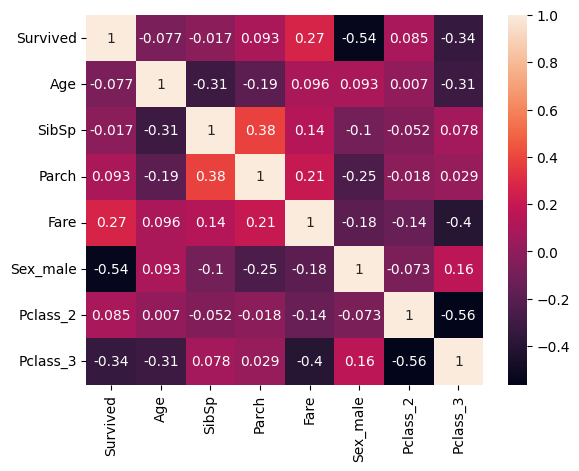

In [22]:
sns.heatmap(train_data_cleaned.corr(), annot=True)
plt.show()

没有明显自相关的变量。

## 进行初步回归

In [23]:
y_0 = train_data_cleaned['Survived']

In [24]:
X_0 = train_data_cleaned.drop('Survived',axis=1)

In [25]:
model_0 = sm.Logit(y_0,X_0).fit()
model_0.summary()

Optimization terminated successfully.
         Current function value: 0.499808
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      707
Method:                           MLE   Df Model:                            6
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                  0.2600
Time:                        12:22:58   Log-Likelihood:                -356.86
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 2.779e-51
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Age            0.0030      0.005      0.559      0.576      -0.008       0.014
SibSp         -0.1913      0.118     -1.620      0.105      -0.423       0.040
Parch         -0.0716      0.116     -0.618      0.537      -0.299       0.156
Fare           0.0187      0.003      5.365      0.000       0.012       0.026
Sex_male      -2.0462      0.193    -10.608      0.000      -2.424      -1.668
Pclass_2       0.7077      0.227      3.124      0.002       0.264       1.152
Pclass_3      -0.0787      0.206     -0.382      0.703      -0.483       0.325
==============================================================================
"""

发现了两个明显无关的变量：年龄'Age'和同乘父母/孩子数量'Parch'。

## 一种思路：把'Age'变量进行转换

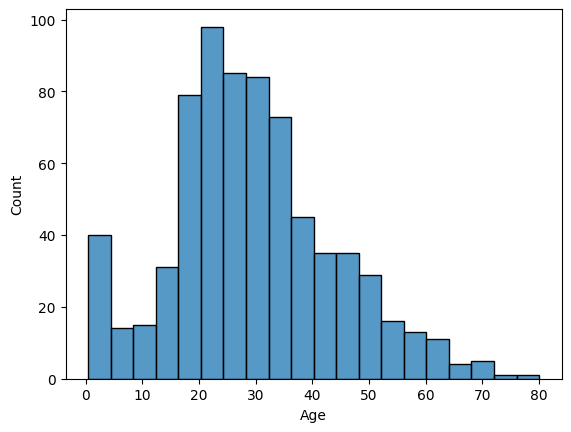

In [26]:
age_plot = sns.histplot(titanic_train['Age'])
plt.show()

In [27]:
for i in range(len(train_data_cleaned)):
    age = train_data_cleaned.loc[i, 'Age']
    
    if age < 18:
        train_data_cleaned.loc[i, 'Age_group'] = '未成年'
    elif age < 30:
        train_data_cleaned.loc[i, 'Age_group'] = '青年'
    elif age < 50:
        train_data_cleaned.loc[i, 'Age_group'] = '中年'
    else:
        train_data_cleaned.loc[i, 'Age_group'] = '老年'
train_data_cleaned

,Survived,Age,SibSp,Parch,Fare,Sex_male,Pclass_2,Pclass_3,Age_group
0,0,22.0,1,0,7.2500,1,0,1,青年
1,1,38.0,1,0,71.2833,0,0,0,中年
2,1,26.0,0,0,7.9250,0,0,1,青年
3,1,35.0,1,0,53.1000,0,0,0,中年
4,0,35.0,0,0,8.0500,1,0,1,中年
...,...,...,...,...,...,...,...,...,...
709,0,39.0,0,5,29.1250,0,0,1,中年
710,0,27.0,0,0,13.0000,1,1,0,青年
711,1,19.0,0,0,30.0000,0,0,0,青年
712,1,26.0,0,0,30.0000,1,0,0,青年


In [28]:
train_data_new = pd.get_dummies(train_data_cleaned, columns=['Age_group'], drop_first=True, dtype=int)
train_data_new = train_data_new.drop('Parch',axis=1)
train_data_new

,Survived,Age,SibSp,Fare,Sex_male,Pclass_2,Pclass_3,Age_group_未成年,Age_group_老年,Age_group_青年
0,0,22.0,1,7.2500,1,0,1,0,0,1
1,1,38.0,1,71.2833,0,0,0,0,0,0
2,1,26.0,0,7.9250,0,0,1,0,0,1
3,1,35.0,1,53.1000,0,0,0,0,0,0
4,0,35.0,0,8.0500,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
709,0,39.0,0,29.1250,0,0,1,0,0,0
710,0,27.0,0,13.0000,1,1,0,0,0,1
711,1,19.0,0,30.0000,0,0,0,0,0,1
712,1,26.0,0,30.0000,1,0,0,0,0,1


In [29]:
X_new = train_data_new.drop(['Survived'],axis=1)
X_new

,Age,SibSp,Fare,Sex_male,Pclass_2,Pclass_3,Age_group_未成年,Age_group_老年,Age_group_青年
0,22.0,1,7.2500,1,0,1,0,0,1
1,38.0,1,71.2833,0,0,0,0,0,0
2,26.0,0,7.9250,0,0,1,0,0,1
3,35.0,1,53.1000,0,0,0,0,0,0
4,35.0,0,8.0500,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
709,39.0,0,29.1250,0,0,1,0,0,0
710,27.0,0,13.0000,1,1,0,0,0,1
711,19.0,0,30.0000,0,0,0,0,0,1
712,26.0,0,30.0000,1,0,0,0,0,1


In [30]:
y_new = train_data_new['Survived']
y_new

0      0
1      1
2      1
3      1
4      0
      ..
709    0
710    0
711    1
712    1
713    0
Name: Survived, Length: 714, dtype: int64

In [31]:
model_1 = sm.Logit(y_new,X_new).fit()
model_1.summary()

Optimization terminated successfully.
         Current function value: 0.460321
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      705
Method:                           MLE   Df Model:                            8
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                  0.3185
Time:                        12:22:59   Log-Likelihood:                -328.67
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 1.221e-61
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age               0.0434      0.008      5.393      0.000       0.028       0.059
SibSp            -0.4301      0.127     -3.393      0.001      -0.679      -0.182
Fare              0.0068      0.003      2.340      0.019       0.001       0.012
Sex_male         -2.4090      0.207    -11.611      0.000      -2.816      -2.002
Pclass_2         -0.4628      0.286     -1.620      0.105      -1.023       0.097
Pclass_3         -1.6593      0.305     -5.446      0.000      -2.256      -1.062
Age_group_未成年     2.8018      0.403      6.951      0.000       2.012       3.592
Age_group_老年     -1.3663      0.413     -3.308      0.001      -2.176      -0.557
Age_group_青年      0.8053      0.244      3.296      0.001       0.326       1.284
=================================================================================
"""

## 模型预测

In [32]:
titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [39]:
test_raw = titanic_test.drop(['Name','PassengerId','Ticket','Cabin','Embarked','Parch'],axis=1).dropna()
test_raw = test_raw.reset_index(drop=True)
test_raw

,Pclass,Sex,Age,SibSp,Fare
0,3,male,34.5,0,7.8292
1,3,female,47.0,1,7.0000
2,2,male,62.0,0,9.6875
3,3,male,27.0,0,8.6625
4,3,female,22.0,1,12.2875
...,...,...,...,...,...
327,3,female,3.0,1,13.7750
328,1,female,37.0,1,90.0000
329,3,female,28.0,0,7.7750
330,1,female,39.0,0,108.9000


In [40]:
for i in range(len(test_raw)):
    age = test_raw.loc[i, 'Age']
    
    if age < 18:
        test_raw.loc[i, 'Age_group'] = '未成年'
    elif age < 30:
        test_raw.loc[i, 'Age_group'] = '青年'
    elif age < 50:
        test_raw.loc[i, 'Age_group'] = '中年'
    else:
        test_raw.loc[i, 'Age_group'] = '老年'
test_raw

,Pclass,Sex,Age,SibSp,Fare,Age_group
0,3,male,34.5,0,7.8292,中年
1,3,female,47.0,1,7.0000,中年
2,2,male,62.0,0,9.6875,老年
3,3,male,27.0,0,8.6625,青年
4,3,female,22.0,1,12.2875,青年
...,...,...,...,...,...,...
327,3,female,3.0,1,13.7750,未成年
328,1,female,37.0,1,90.0000,中年
329,3,female,28.0,0,7.7750,青年
330,1,female,39.0,0,108.9000,中年


In [42]:
test_data = pd.get_dummies(test_raw, columns=['Sex','Pclass','Age_group'], drop_first=True, dtype=int)
test_data

,Age,SibSp,Fare,Sex_male,Pclass_2,Pclass_3,Age_group_未成年,Age_group_老年,Age_group_青年
0,34.5,0,7.8292,1,0,1,0,0,0
1,47.0,1,7.0000,0,0,1,0,0,0
2,62.0,0,9.6875,1,1,0,0,1,0
3,27.0,0,8.6625,1,0,1,0,0,1
4,22.0,1,12.2875,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
327,3.0,1,13.7750,0,0,1,1,0,0
328,37.0,1,90.0000,0,0,0,0,0,0
329,28.0,0,7.7750,0,0,1,0,0,1
330,39.0,0,108.9000,0,0,0,0,0,0


In [43]:
forcast_0 = model_1.predict(test_data)
forcast_0

0      0.074662
1      0.499709
2      0.185382
3      0.115893
4      0.438890
         ...   
327    0.718266
328    0.856337
329    0.602162
330    0.919085
331    0.087272
Length: 332, dtype: float64

In [45]:
test_data['Surviving possibility'] = forcast_0
test_data

,Age,SibSp,Fare,Sex_male,Pclass_2,Pclass_3,Age_group_未成年,Age_group_老年,Age_group_青年,Surviving possibility
0,34.5,0,7.8292,1,0,1,0,0,0,0.074662
1,47.0,1,7.0000,0,0,1,0,0,0,0.499709
2,62.0,0,9.6875,1,1,0,0,1,0,0.185382
3,27.0,0,8.6625,1,0,1,0,0,1,0.115893
4,22.0,1,12.2875,0,0,1,0,0,1,0.438890
...,...,...,...,...,...,...,...,...,...,...
327,3.0,1,13.7750,0,0,1,1,0,0,0.718266
328,37.0,1,90.0000,0,0,0,0,0,0,0.856337
329,28.0,0,7.7750,0,0,1,0,0,1,0.602162
330,39.0,0,108.9000,0,0,0,0,0,0,0.919085
